=== SYNTHÈSE DES MODÈLES ===
                     Méthode                        Type         Métrique                  Interprétation
Régression linéaire multiple     Supervisée (régression)       R² = 0.317     31.7% de variance expliquée
 Analyse discriminante (LDA) Supervisée (classification) Accuracy = 0.588 58.8% de bonnes classifications
    Arbre de décision (CART) Supervisée (classification) Accuracy = 0.568 56.8% de bonnes classifications


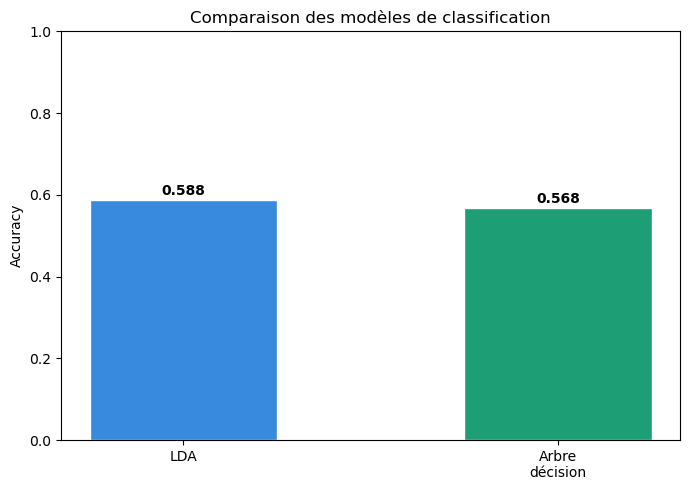


=== CONCLUSIONS ===
  Meilleur modèle de classification : LDA
  Variables les plus importantes : alcohol, volatile acidity, sulphates
  La qualité du vin est principalement déterminée par le degré d'alcool
  et l'acidité volatile (corrélation négative avec la qualité).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

df   = pd.read_csv("df_prepared.csv")
X_cr = pd.read_csv("X_cr.csv")

X = X_cr.values
y_cat = df['quality_cat'].values
y_num = df['quality'].values

X_train, X_test, yc_train, yc_test, yn_train, yn_test = train_test_split(
    X, y_cat, y_num, test_size=0.25, random_state=42, stratify=y_cat)

# --- Régression linéaire multiple (R²) ---
lr = LinearRegression().fit(X_train, yn_train)
r2 = r2_score(yn_test, lr.predict(X_test))

# --- LDA ---
lda = LinearDiscriminantAnalysis().fit(X_train, yc_train)
acc_lda = accuracy_score(yc_test, lda.predict(X_test))

# --- Arbre de décision ---
dt = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, yc_train)
acc_dt = accuracy_score(yc_test, dt.predict(X_test))

# --- Tableau de synthèse ---
synthese = pd.DataFrame({
    'Méthode': ['Régression linéaire multiple', 'Analyse discriminante (LDA)',
                'Arbre de décision (CART)'],
    'Type': ['Supervisée (régression)', 'Supervisée (classification)',
             'Supervisée (classification)'],
    'Métrique': [f'R² = {r2:.3f}', f'Accuracy = {acc_lda:.3f}',
                 f'Accuracy = {acc_dt:.3f}'],
    'Interprétation': [
        f'{r2*100:.1f}% de variance expliquée',
        f'{acc_lda*100:.1f}% de bonnes classifications',
        f'{acc_dt*100:.1f}% de bonnes classifications'
    ]
})
print("=== SYNTHÈSE DES MODÈLES ===")
print(synthese.to_string(index=False))

# --- Graphique comparatif accuracy ---
modeles = ['LDA', 'Arbre\ndécision']
accuracies = [acc_lda, acc_dt]

plt.figure(figsize=(7, 5))
bars = plt.bar(modeles, accuracies, color=['#378ADD', '#1D9E75'],
               edgecolor='white', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Comparaison des modèles de classification")
plt.tight_layout()
plt.savefig("comparaison_modeles.png", dpi=150)
plt.show()

print("\n=== CONCLUSIONS ===")
best = 'LDA' if acc_lda > acc_dt else 'Arbre de décision'
print(f"  Meilleur modèle de classification : {best}")
print(f"  Variables les plus importantes : alcohol, volatile acidity, sulphates")
print(f"  La qualité du vin est principalement déterminée par le degré d'alcool")
print(f"  et l'acidité volatile (corrélation négative avec la qualité).")